Modelo Juan Felipe Echeverry

# Modelo de Regresión — Predicción de Puntaje Global Saber 11

**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Juan Felipe Echeverry  
**Rol:** Ciencia de Datos  

## Contexto

Este notebook desarrolla un modelo predictivo de regresión basado en redes neuronales para estimar el **puntaje global** que un estudiante obtendría en la prueba Saber 11, a partir de sus características socioeconómicas, demográficas y del colegio en el que estudia.

**Usuario final:** Secretaría de Educación de Bolívar.

**Pregunta de negocio:** ¿Qué factores socioeconómicos, demográficos y del entorno escolar permiten predecir el puntaje global Saber 11 de los estudiantes de Bolívar, y cómo puede la Secretaría de Educación estimar el puntaje esperado de distintos perfiles de estudiante para focalizar programas de refuerzo académico en las poblaciones con mayor riesgo de bajo desempeño?

## 1. Carga de datos limpios

Cargamos el dataframe ya procesado por el script de limpieza `Proyecto2.py`

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [10]:
df = pd.read_csv('DatosSaber11_Bolivar_limpio_todas_columnas.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()
df.dtypes

Filas: 122,866
Columnas: 52


estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object
cole_cod_dane_es

## 2. Exploración del target: `punt_global`

El `punt_global` es nuestra variable objetivo. Está en escala 0–500 (suma ponderada de las áreas evaluadas). Revisamos su distribución antes de modelar.

In [11]:
df['punt_global'].describe()

count    122866.000000
mean        236.134561
std          48.642475
min           0.000000
25%         200.000000
50%         229.000000
75%         266.000000
max         475.000000
Name: punt_global, dtype: float64

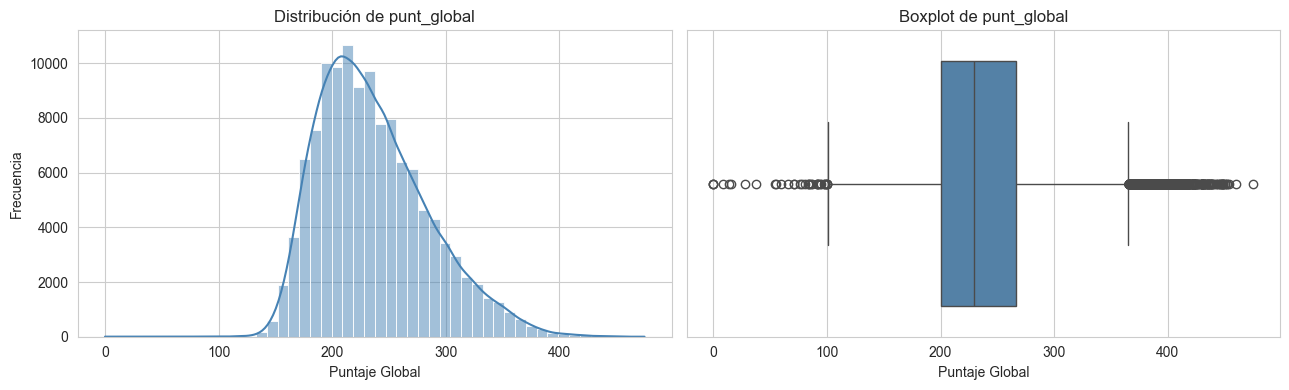

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
sns.histplot(df['punt_global'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de punt_global')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df['punt_global'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de punt_global')
axes[1].set_xlabel('Puntaje Global')

plt.tight_layout()
plt.show()

In [13]:
# Verificación de valores nulos en el dataframe
nulos = df.isna().sum()
print("Columnas con nulos:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Ninguna columna tiene nulos.")

Columnas con nulos:
Ninguna columna tiene nulos.


## 3. Categorías de las variables ordinales

Antes de pasar al modelado, revisamos los valores únicos de las variables categóricas que vamos a tratar como ordinales (estrato, educación de padres, número de personas y cuartos en el hogar). Esto nos permite definir el mapeo correcto a valores numéricos.

In [14]:
variables_a_revisar = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
    'cole_jornada',
    'cole_caracter',
    'cole_calendario',
    'cole_naturaleza',
    'cole_genero',
    'estu_genero',
    'cole_bilingue',
    'cole_area_ubicacion',
]

for col in variables_a_revisar:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))


--- fami_estratovivienda ---
fami_estratovivienda
ESTRATO 1      69347
ESTRATO 2      28357
ESTRATO 3      13142
ESTRATO 4       4294
SIN ESTRATO     4136
ESTRATO 5       2101
ESTRATO 6       1489
Name: count, dtype: int64

--- fami_educacionmadre ---
fami_educacionmadre
SECUNDARIA (BACHILLERATO) COMPLETA      33159
SECUNDARIA (BACHILLERATO) INCOMPLETA    21277
PRIMARIA INCOMPLETA                     16979
PRIMARIA COMPLETA                       13821
TECNICA O TECNOLOGICA COMPLETA          11981
EDUCACION PROFESIONAL COMPLETA          11905
TECNICA O TECNOLOGICA INCOMPLETA         3873
NINGUNO                                  3184
NO SABE                                  2538
POSTGRADO                                2070
EDUCACION PROFESIONAL INCOMPLETA         1966
NO APLICA                                 113
Name: count, dtype: int64

--- fami_educacionpadre ---
fami_educacionpadre
SECUNDARIA (BACHILLERATO) COMPLETA      30321
SECUNDARIA (BACHILLERATO) INCOMPLETA    20307
PRIMARIA

## 4. Selección de features y exclusiones

Antes de modelar definimos qué variables usamos como predictoras (`features`) y cuáles descartamos.

### Variables excluidas

- **Por fuga de información (data leakage)**: las cinco pruebas individuales (`punt_ingles`, `punt_matematicas`, `punt_lectura_critica`, `punt_c_naturales`, `punt_sociales_ciudadanas`) y `desemp_ingles`. El puntaje global es función directa de esas pruebas, así que incluirlas convertiría la predicción en una operación aritmética sin valor.
- **Identificadores y códigos administrativos**: `estu_consecutivo`, `cole_cod_dane_establecimiento`, `cole_cod_dane_sede`, `cole_codigo_icfes`, `cole_cod_depto_ubicacion`, `cole_cod_mcpio_ubicacion`, `estu_cod_*`, `estu_tipodocumento`, `estu_estadoinvestigacion`, `estu_estudiante`.
- **Nombres propios (no generalizan)**: `cole_nombre_establecimiento`, `cole_nombre_sede`.
- **Variables casi constantes en Bolívar**: `estu_nacionalidad`, `estu_pais_reside`, `estu_privado_libertad`, `cole_sede_principal`, `cole_depto_ubicacion`, `estu_depto_presentacion`, `estu_depto_reside`.
- **Redundantes con `edad`**: `estu_fechanacimiento`.
- **Geográficas finas (decisión consciente, ver más adelante)**: `cole_mcpio_ubicacion`, `estu_mcpio_presentacion`, `estu_mcpio_reside`. Se excluyen en esta primera versión para evitar la explosión de columnas (46 municipios). Si el modelo lo justifica, se pueden incorporar en una iteración posterior.
- **Periodo**: `periodo`. No es predictor del puntaje individual, sino marcador temporal.

In [15]:
# Definimos las variables a usar como features
target = 'punt_global'

features_binarias = [
    'cole_bilingue',
    'cole_area_ubicacion',
    'cole_naturaleza',
    'fami_tieneautomovil',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tienelavadora',
    'estu_genero',
]

features_ordinales = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
]

features_nominales = [
    'cole_calendario',
    'cole_caracter',
    'cole_jornada',
    'cole_genero',
]

features_numericas = ['edad']

todas_las_features = (features_binarias + features_ordinales + 
                     features_nominales + features_numericas)

print(f"Total de features seleccionadas: {len(todas_las_features)}")
print(f"  - Binarias: {len(features_binarias)}")
print(f"  - Ordinales: {len(features_ordinales)}")
print(f"  - Nominales: {len(features_nominales)}")
print(f"  - Numéricas: {len(features_numericas)}")

Total de features seleccionadas: 18
  - Binarias: 8
  - Ordinales: 5
  - Nominales: 4
  - Numéricas: 1


In [16]:
# Construimos el dataframe de trabajo solo con features + target
df_modelo = df[todas_las_features + [target]].copy()
print(f"Shape df_modelo: {df_modelo.shape}")
df_modelo.head()

Shape df_modelo: (122866, 19)


,cole_bilingue,cole_area_ubicacion,cole_naturaleza,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,estu_genero,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,cole_calendario,cole_caracter,cole_jornada,cole_genero,edad,punt_global
0,N,URBANO,OFICIAL,No,NO,NO,Si,M,ESTRATO 1,SECUNDARIA (BACHILLERATO) COMPLETA,PRIMARIA COMPLETA,Uno,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,17,226.0
1,N,URBANO,OFICIAL,No,SI,SI,Si,M,ESTRATO 3,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,Tres,5 a 6,A,TECNICO/ACADEMICO,TARDE,MIXTO,17,348.0
2,N,URBANO,OFICIAL,No,NO,NO,Si,F,ESTRATO 3,SECUNDARIA (BACHILLERATO) COMPLETA,NINGUNO,Tres,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,16,160.0
3,N,RURAL,OFICIAL,No,NO,SI,Si,M,SIN ESTRATO,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,Dos,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,17,164.0
4,N,URBANO,OFICIAL,No,SI,SI,Si,F,ESTRATO 1,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,Tres,3 a 4,A,ACADEMICO,NOCHE,MIXTO,18,252.0


## 5. Codificación de variables

### 5.1 Variables binarias

Las variables binarias se convierten a 0/1. Mapeo:
- `cole_bilingue`: S → 1, N → 0
- `cole_area_ubicacion`: URBANO → 1, RURAL → 0
- `cole_naturaleza`: NO OFICIAL → 1, OFICIAL → 0
- `fami_tiene*`: Si → 1, No → 0
- `estu_genero`: M → 1, F → 0

In [17]:
# Primero exploramos los valores únicos de las binarias "fami_tiene*"
# (no las hemos revisado todavía)
for col in ['fami_tieneautomovil', 'fami_tienecomputador', 
            'fami_tieneinternet', 'fami_tienelavadora']:
    print(f"{col}: {df_modelo[col].unique()}")

fami_tieneautomovil: ['No' 'Si']
fami_tienecomputador: ['NO' 'SI']
fami_tieneinternet: ['NO' 'SI']
fami_tienelavadora: ['Si' 'No']


Las binarias vienen con formatos mezclados ("Si"/"No" en algunas columnas, "SI"/"NO" en otras). Lo normalizamos a un solo mapeo aceptando ambos.

In [18]:
mapeo_si_no = {'SI': 1, 'Si': 1, 'NO': 0, 'No': 0}

df_modelo['cole_bilingue'] = df_modelo['cole_bilingue'].map({'S': 1, 'N': 0})
df_modelo['cole_area_ubicacion'] = df_modelo['cole_area_ubicacion'].map({'URBANO': 1, 'RURAL': 0})
df_modelo['cole_naturaleza'] = df_modelo['cole_naturaleza'].map({'NO OFICIAL': 1, 'OFICIAL': 0})
df_modelo['fami_tieneautomovil'] = df_modelo['fami_tieneautomovil'].map(mapeo_si_no)
df_modelo['fami_tienecomputador'] = df_modelo['fami_tienecomputador'].map(mapeo_si_no)
df_modelo['fami_tieneinternet'] = df_modelo['fami_tieneinternet'].map(mapeo_si_no)
df_modelo['fami_tienelavadora'] = df_modelo['fami_tienelavadora'].map(mapeo_si_no)
df_modelo['estu_genero'] = df_modelo['estu_genero'].map({'M': 1, 'F': 0})

print("Nulos después del mapeo binario:")
print(df_modelo[features_binarias].isna().sum())

Nulos después del mapeo binario:
cole_bilingue           0
cole_area_ubicacion     0
cole_naturaleza         0
fami_tieneautomovil     0
fami_tienecomputador    0
fami_tieneinternet      0
fami_tienelavadora      0
estu_genero             0
dtype: int64


### 5.2 Variables ordinales

Convertimos a un número entero respetando el orden natural de cada variable.

- **Estrato vivienda**: "SIN ESTRATO" se mapea a 0, Estratos 1–6 a 1–6.
- **Educación de padres**: 0 (ninguno / no sabe / no aplica) hasta 9 (postgrado). Las categorías "NO SABE" y "NO APLICA" se asignan a 0 por baja representatividad (<3%) y porque tienden a coincidir con perfiles de baja escolaridad.
- **Cuartos y personas del hogar**: se unifican los formatos mezclados (palabras como "Dos", rangos como "3 a 4", etc.) a un único entero.

In [19]:
# Estrato
mapa_estrato = {
    'SIN ESTRATO': 0,
    'ESTRATO 1': 1, 'ESTRATO 2': 2, 'ESTRATO 3': 3,
    'ESTRATO 4': 4, 'ESTRATO 5': 5, 'ESTRATO 6': 6,
}
df_modelo['fami_estratovivienda'] = df_modelo['fami_estratovivienda'].map(mapa_estrato)

# Educación padre y madre
mapa_educacion = {
    'NINGUNO': 0, 'NO SABE': 0, 'NO APLICA': 0,
    'PRIMARIA INCOMPLETA': 1,
    'PRIMARIA COMPLETA': 2,
    'SECUNDARIA (BACHILLERATO) INCOMPLETA': 3,
    'SECUNDARIA (BACHILLERATO) COMPLETA': 4,
    'TECNICA O TECNOLOGICA INCOMPLETA': 5,
    'TECNICA O TECNOLOGICA COMPLETA': 6,
    'EDUCACION PROFESIONAL INCOMPLETA': 7,
    'EDUCACION PROFESIONAL COMPLETA': 8,
    'POSTGRADO': 9,
}
df_modelo['fami_educacionmadre'] = df_modelo['fami_educacionmadre'].map(mapa_educacion)
df_modelo['fami_educacionpadre'] = df_modelo['fami_educacionpadre'].map(mapa_educacion)

# Cuartos del hogar
mapa_cuartos = {
    'Uno': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4, 'Cinco': 5,
    'Seis': 6, 'Seis o mas': 6, 'Siete': 7, 'Ocho': 8, 
    'Nueve': 9, 'Diez o más': 10,
}
df_modelo['fami_cuartoshogar'] = df_modelo['fami_cuartoshogar'].map(mapa_cuartos)

# Personas del hogar (formatos mezclados)
mapa_personas = {
    'Una': 1, '1 a 2': 1,
    'Dos': 2,
    'Tres': 3, '3 a 4': 3,
    'Cuatro': 4,
    'Cinco': 5, '5 a 6': 5,
    'Seis': 6,
    'Siete': 7, '7 a 8': 7,
    'Ocho': 8,
    'Nueve': 9, '9 o más': 9,
    'Diez': 10,
    'Once': 11,
    'Doce o más': 12,
}
df_modelo['fami_personashogar'] = df_modelo['fami_personashogar'].map(mapa_personas)

print("Nulos después del mapeo ordinal:")
print(df_modelo[features_ordinales].isna().sum())

Nulos después del mapeo ordinal:
fami_estratovivienda    0
fami_educacionmadre     0
fami_educacionpadre     0
fami_cuartoshogar       0
fami_personashogar      0
dtype: int64


### 5.3 Variables nominales

Para las categóricas sin orden natural usamos **one-hot encoding** con `pd.get_dummies` (mismo enfoque del starter de clase con la variable `Origin`).

In [20]:
df_modelo = pd.get_dummies(
    df_modelo, 
    columns=features_nominales, 
    prefix=features_nominales,
    dtype=int
)

print(f"Shape después de one-hot: {df_modelo.shape}")
df_modelo.head()

Shape después de one-hot: (122866, 30)


,cole_bilingue,cole_area_ubicacion,cole_naturaleza,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,estu_genero,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,edad,punt_global,cole_calendario_A,cole_calendario_B,cole_caracter_ACADEMICO,cole_caracter_NO APLICA,cole_caracter_TECNICO,cole_caracter_TECNICO/ACADEMICO,cole_jornada_COMPLETA,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_TARDE,cole_jornada_UNICA,cole_genero_FEMENINO,cole_genero_MASCULINO,cole_genero_MIXTO
0,0,1,0,0,0,0,1,1,1,4,2,1,3,17,226.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
1,0,1,0,0,1,1,1,1,3,8,8,3,5,17,348.0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1
2,0,1,0,0,0,0,1,0,3,4,0,3,3,16,160.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
3,0,0,0,0,0,1,1,1,0,4,4,2,3,17,164.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
4,0,1,0,0,1,1,1,0,1,5,5,3,3,18,252.0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1


In [21]:
print("Tipos de datos del df_modelo:")
print(df_modelo.dtypes)
print("\nNulos totales en df_modelo:", df_modelo.isna().sum().sum())

Tipos de datos del df_modelo:
cole_bilingue                        int64
cole_area_ubicacion                  int64
cole_naturaleza                      int64
fami_tieneautomovil                  int64
fami_tienecomputador                 int64
fami_tieneinternet                   int64
fami_tienelavadora                   int64
estu_genero                          int64
fami_estratovivienda                 int64
fami_educacionmadre                  int64
fami_educacionpadre                  int64
fami_cuartoshogar                    int64
fami_personashogar                   int64
edad                                 int64
punt_global                        float64
cole_calendario_A                    int64
cole_calendario_B                    int64
cole_caracter_ACADEMICO              int64
cole_caracter_NO APLICA              int64
cole_caracter_TECNICO                int64
cole_caracter_TECNICO/ACADEMICO      int64
cole_jornada_COMPLETA                int64
cole_jornada_MAÑANA     

In [22]:
print(f"Shape final del df_modelo: {df_modelo.shape}")
print(f"\nLista completa de columnas:")
for col in df_modelo.columns:
    print(f"  - {col}")

Shape final del df_modelo: (122866, 30)

Lista completa de columnas:
  - cole_bilingue
  - cole_area_ubicacion
  - cole_naturaleza
  - fami_tieneautomovil
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tienelavadora
  - estu_genero
  - fami_estratovivienda
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar
  - edad
  - punt_global
  - cole_calendario_A
  - cole_calendario_B
  - cole_caracter_ACADEMICO
  - cole_caracter_NO APLICA
  - cole_caracter_TECNICO
  - cole_caracter_TECNICO/ACADEMICO
  - cole_jornada_COMPLETA
  - cole_jornada_MAÑANA
  - cole_jornada_NOCHE
  - cole_jornada_SABATINA
  - cole_jornada_TARDE
  - cole_jornada_UNICA
  - cole_genero_FEMENINO
  - cole_genero_MASCULINO
  - cole_genero_MIXTO


## 6. Análisis exploratorio post-encoding

Antes de modelar revisamos:
1. La **correlación de cada feature con el target** (`punt_global`) para identificar las variables con mayor poder predictivo lineal.
2. La **matriz de correlación entre features** para detectar multicolinealidad (variables que aportan información redundante).

Aunque las redes neuronales pueden capturar relaciones no lineales y no son tan sensibles a la multicolinealidad como la regresión lineal clásica, estos análisis son útiles para interpretar el problema y justificar decisiones de modelado.

In [23]:
# Correlación de cada feature con el target
corr_target = df_modelo.corr()['punt_global'].drop('punt_global').sort_values(key=abs, ascending=False)

print("Correlación de cada feature con punt_global (ordenada por magnitud):\n")
print(corr_target.to_string())

Correlación de cada feature con punt_global (ordenada por magnitud):

fami_educacionmadre                0.404239
cole_naturaleza                    0.391706
fami_educacionpadre                0.379307
fami_tieneinternet                 0.324898
fami_tienecomputador               0.324644
cole_jornada_COMPLETA              0.319473
fami_estratovivienda               0.281466
fami_tieneautomovil                0.242506
cole_calendario_B                  0.233642
cole_calendario_A                 -0.233642
edad                              -0.232240
cole_jornada_NOCHE                -0.212338
cole_caracter_ACADEMICO            0.185430
cole_genero_MIXTO                 -0.185097
cole_caracter_TECNICO             -0.181943
cole_area_ubicacion                0.179709
cole_genero_FEMENINO               0.176141
cole_bilingue                      0.159233
fami_tienelavadora                 0.140696
cole_jornada_SABATINA             -0.139489
fami_personashogar                -0.114026
cole_g

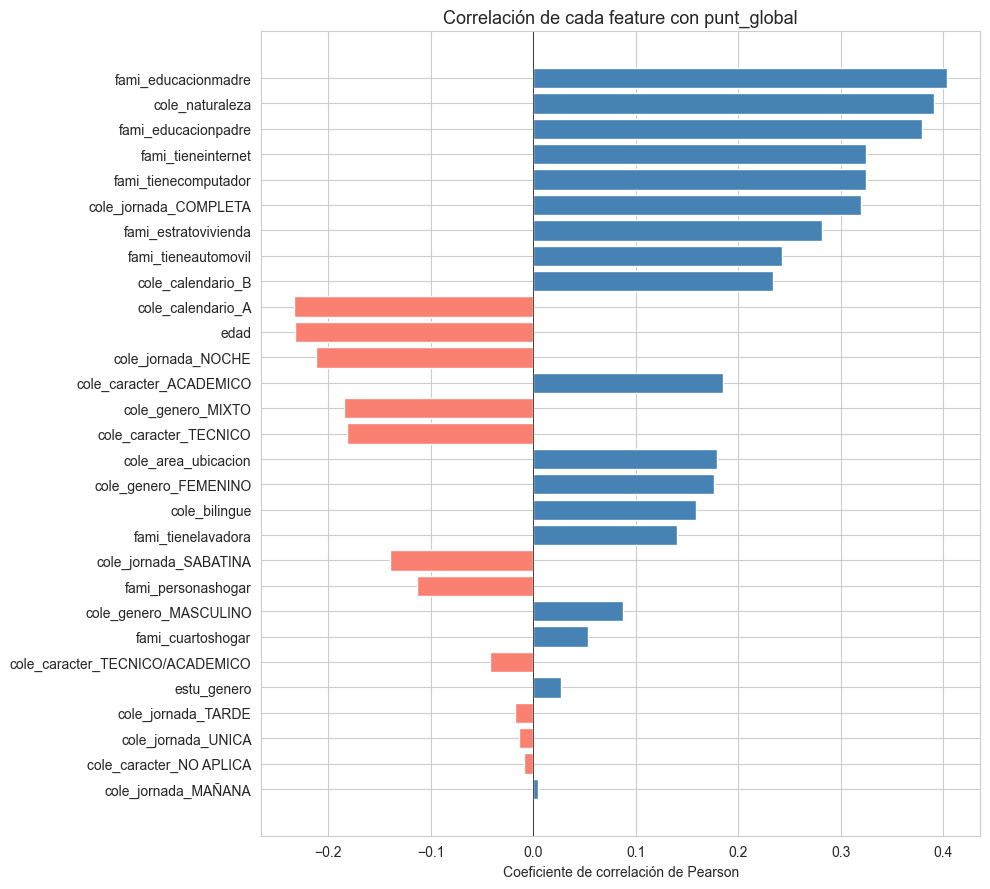

In [24]:
# Visualización: correlaciones con el target en barras horizontales
plt.figure(figsize=(10, 9))
colors = ['steelblue' if x > 0 else 'salmon' for x in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('Correlación de cada feature con punt_global', fontsize=13)
plt.xlabel('Coeficiente de correlación de Pearson')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.1 Matriz de correlación entre features

Visualizamos también la matriz de correlación completa para identificar pares de features altamente correlacionadas entre sí (posible multicolinealidad).

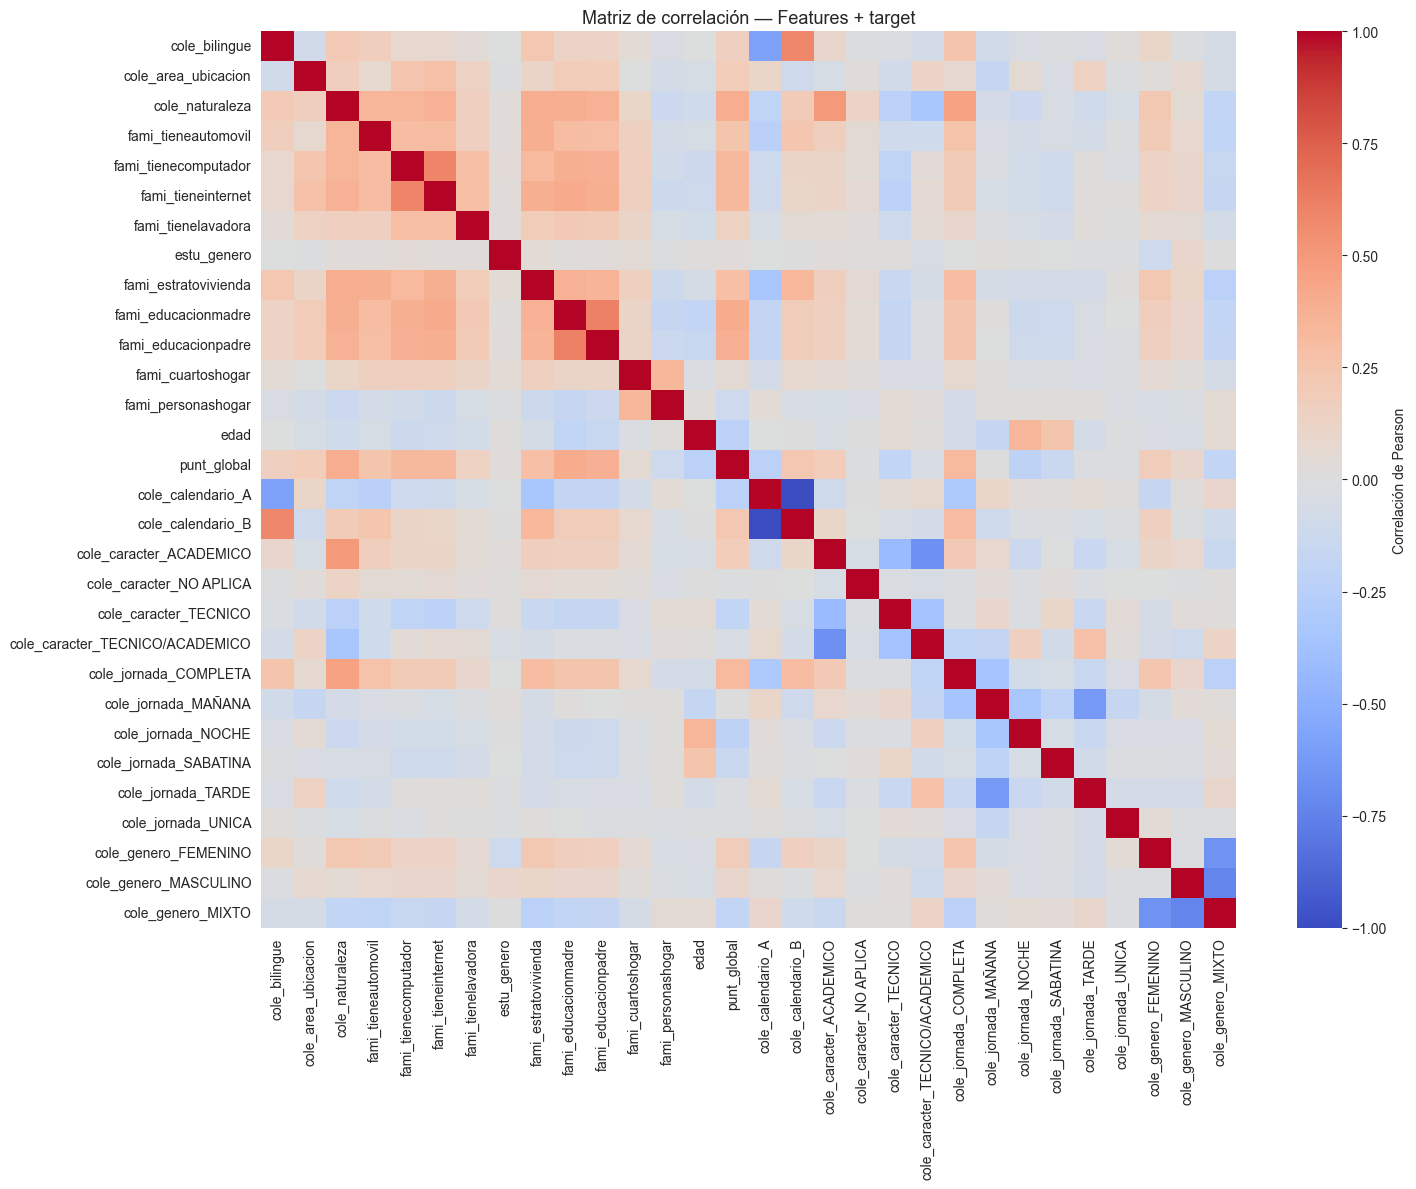

In [25]:
plt.figure(figsize=(15, 12))
matriz_corr = df_modelo.corr()
sns.heatmap(
    matriz_corr, 
    annot=False, 
    cmap='coolwarm', 
    center=0,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlación de Pearson'}
)
plt.title('Matriz de correlación — Features + target', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Identificar pares de features con alta correlación entre sí (> 0.7 o < -0.7)
matriz_features = df_modelo.drop(columns='punt_global').corr()

pares_altos = []
for i in range(len(matriz_features.columns)):
    for j in range(i + 1, len(matriz_features.columns)):
        valor = matriz_features.iloc[i, j]
        if abs(valor) > 0.7:
            pares_altos.append({
                'var_1': matriz_features.columns[i],
                'var_2': matriz_features.columns[j],
                'correlacion': round(valor, 3)
            })

if pares_altos:
    print("Pares de features con correlación absoluta > 0.7:\n")
    print(pd.DataFrame(pares_altos).to_string(index=False))
else:
    print("No se detectaron pares de features con correlación absoluta > 0.7.")

Pares de features con correlación absoluta > 0.7:

                var_1             var_2  correlacion
    cole_calendario_A cole_calendario_B       -1.000
cole_genero_MASCULINO cole_genero_MIXTO       -0.734


### 6.2 Observaciones del análisis exploratorio

**Variables con mayor poder predictivo lineal (correlación |r| > 0.30):**

- `fami_educacionmadre` (+0.40) y `fami_educacionpadre` (+0.38): la educación de los padres es el predictor socioeconómico más fuerte del puntaje del estudiante.
- `cole_naturaleza` (+0.39): los colegios no oficiales (privados) tienen, en promedio, puntajes superiores. Evidencia de brecha entre educación pública y privada en Bolívar.
- `fami_tieneinternet` (+0.32) y `fami_tienecomputador` (+0.32): el acceso a recursos tecnológicos del hogar tiene un peso considerable.
- `cole_jornada_COMPLETA` (+0.32): la jornada única o completa se asocia con mejor desempeño frente a jornadas parciales.

**Variables con asociación negativa relevante:**

- `edad` (-0.23): estudiantes en extraedad (mayor edad al presentar la prueba) tienden a obtener puntajes más bajos, posiblemente reflejo de trayectorias educativas interrumpidas.
- `cole_jornada_NOCHE` (-0.21): la jornada nocturna asocia con menor desempeño, lo cual es consistente con perfiles de estudiantes que trabajan o estudian a contracorriente.

**Variables con correlación cercana a cero:**

- `estu_genero` (+0.03): a nivel del puntaje global, hombres y mujeres en Bolívar muestran desempeños prácticamente equivalentes. Esto no implica equidad en todas las áreas (estudios anteriores muestran que mujeres rinden mejor en lectura crítica y hombres en matemáticas), pero el efecto promedio se compensa.

**Multicolinealidad detectada:**

Se identifican dos pares de features con correlación absoluta superior a 0.7:
- `cole_calendario_A` ↔ `cole_calendario_B` (r = -1.00): correlación perfecta inversa, dado que el calendario es binario.
- `cole_genero_MASCULINO` ↔ `cole_genero_MIXTO` (r = -0.73): correlación alta inversa, explicada por la dominancia de colegios mixtos (~96%).

Aunque las redes neuronales son más robustas a la multicolinealidad que la regresión lineal, eliminar features redundantes simplifica el modelo y mejora la interpretabilidad sin pérdida de información.

## 7. Modelado con redes neuronales

Siguiendo el enfoque del starter de clase (regresión sobre auto-mpg), desarrollamos los modelos en TensorFlow / Keras con la siguiente estrategia incremental:

1. **Modelo baseline lineal**: equivalente a una regresión lineal multivariable, implementada como una red sin capas ocultas. Sirve de piso de referencia.
2. **Modelo DNN inicial**: red neuronal densa con dos capas ocultas y activación ReLU, similar al `dnn_model` del starter.
3. **Modelo DNN ajustado**: variaciones de arquitectura, regularización (Dropout) y learning rate, registradas en MLflow.

Como métrica principal usamos el **MAE** (Mean Absolute Error) porque es interpretable directamente en la escala del puntaje. Complementamos con **RMSE** (penaliza errores grandes) y **R²** (varianza explicada).

### 7.1 Separación train / test

In [27]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


In [28]:
# Separamos en train (80%) y test (20%)
np.random.seed(42) 

train_df = df_modelo.sample(frac=0.8, random_state=42)
test_df = df_modelo.drop(train_df.index)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

Train: (98293, 30)
Test:  (24573, 30)


In [29]:
# Separamos features (X) y target (y)
train_X = train_df.copy()
test_X = test_df.copy()

train_y = train_X.pop('punt_global')
test_y = test_X.pop('punt_global')

print(f"train_X: {train_X.shape}, train_y: {train_y.shape}")
print(f"test_X:  {test_X.shape},  test_y: {test_y.shape}")

train_X: (98293, 29), train_y: (98293,)
test_X:  (24573, 29),  test_y: (24573,)


### 7.2 Capa de normalización

Las features están en escalas muy distintas: edad (~15–25), estrato (0–6), educación (0–9), y las binarias one-hot (0–1). Entrenar una red con escalas tan diferentes hace que el optimizador converja lento o mal.

Usamos la capa `tf.keras.layers.Normalization`, que aprende la media y la desviación estándar de los datos de entrenamiento con `.adapt()` y los aplica automáticamente a cualquier input que reciba el modelo después.

In [30]:
# Creamos la capa de normalización adaptada a los datos de entrenamiento
normalizador = tf.keras.layers.Normalization()
normalizador.adapt(np.array(train_X))

# Verificación: media y std aprendidas (deberían coincidir con train_X)
print("Primeros 5 valores de la media aprendida:")
print(normalizador.mean.numpy()[0][:5])
print("\nPrimeros 5 valores de la desviación estándar aprendida:")
print(np.sqrt(normalizador.variance.numpy()[0][:5]))

Primeros 5 valores de la media aprendida:
[0.01857711 0.820679   0.18893512 0.13303083 0.42422146]

Primeros 5 valores de la desviación estándar aprendida:
[0.13502593 0.3836209  0.39145708 0.33960804 0.49422425]


### 7.3 Modelo baseline: regresión lineal multivariable

Construimos primero el modelo más simple posible: una sola capa densa con una neurona y sin activación. Esto equivale matemáticamente a una regresión lineal y nos da el piso contra el cual comparar los modelos más complejos.

**Arquitectura:**
- Entrada: 28 features
- Capa de normalización
- Capa densa con 1 neurona (salida = predicción del puntaje)

**Configuración de entrenamiento:**
- Optimizador: Adam (learning rate = 0.1)
- Función de pérdida: MAE
- Validación: 20% del set de entrenamiento
- Épocas: 100

In [31]:
n_features = train_X.shape[1]
print(f"Número de features de entrada: {n_features}")

# Definimos el modelo lineal
input_layer = tf.keras.layers.Input(shape=(n_features,))

modelo_lineal = tf.keras.Sequential([
    input_layer,
    normalizador,
    tf.keras.layers.Dense(units=1)
])

modelo_lineal.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

modelo_lineal.summary()

Número de features de entrada: 29


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 29)             │            59 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (360.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 59 (240.00 B)

In [32]:
%%time
history_lineal = modelo_lineal.fit(
    train_X,
    train_y,
    epochs=100,
    validation_split=0.2,
    verbose=0  # silenciamos los logs por época para no llenar el notebook
)
print("Entrenamiento finalizado.")

Entrenamiento finalizado.
CPU times: user 12min 3s, sys: 1min 34s, total: 13min 37s
Wall time: 10min 11s


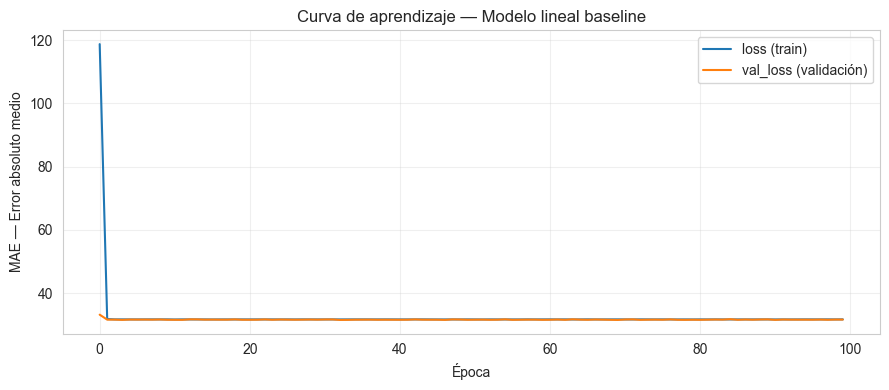


MAE final entrenamiento: 31.728
MAE final validación:    31.662


In [33]:
# Visualizamos la evolución de la pérdida
plt.figure(figsize=(9, 4))
plt.plot(history_lineal.history['loss'], label='loss (train)')
plt.plot(history_lineal.history['val_loss'], label='val_loss (validación)')
plt.xlabel('Época')
plt.ylabel('MAE — Error absoluto medio')
plt.title('Curva de aprendizaje — Modelo lineal baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Valores finales
print(f"\nMAE final entrenamiento: {history_lineal.history['loss'][-1]:.3f}")
print(f"MAE final validación:    {history_lineal.history['val_loss'][-1]:.3f}")

In [34]:
# Evaluamos el modelo en el set de test (datos nunca vistos)
resultados = {}

mae_test_lineal = modelo_lineal.evaluate(test_X, test_y, verbose=0)
resultados['Modelo lineal'] = {'MAE_test': mae_test_lineal}

print(f"MAE en test del modelo lineal: {mae_test_lineal:.3f}")
print(f"\nInterpretación: en promedio el modelo se equivoca en {mae_test_lineal:.1f} puntos al predecir un puntaje (escala 0–500).")

MAE en test del modelo lineal: 31.667

Interpretación: en promedio el modelo se equivoca en 31.7 puntos al predecir un puntaje (escala 0–500).


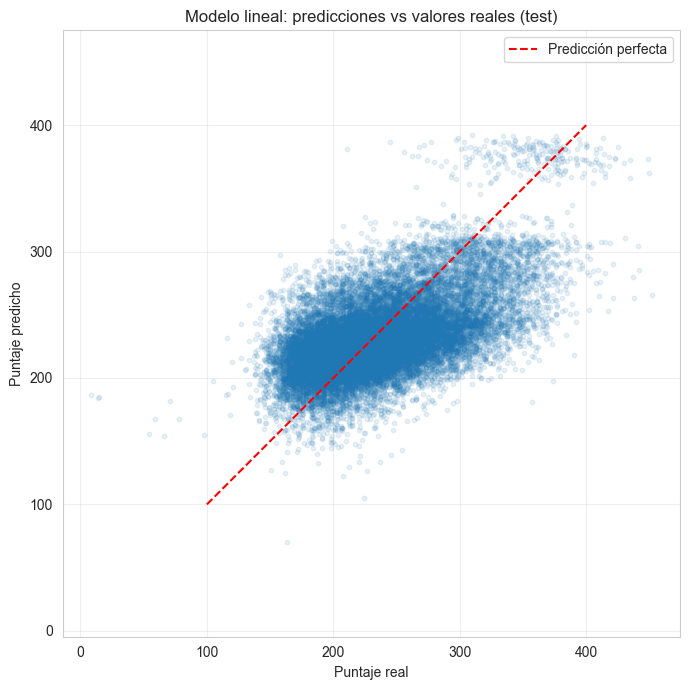

In [35]:
# Predicciones vs valores reales
predicciones_lineal = modelo_lineal.predict(test_X, verbose=0).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(test_y, predicciones_lineal, alpha=0.1, s=10)
plt.plot([100, 400], [100, 400], 'r--', label='Predicción perfecta')
plt.xlabel('Puntaje real')
plt.ylabel('Puntaje predicho')
plt.title('Modelo lineal: predicciones vs valores reales (test)')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lineal = mean_absolute_error(test_y, predicciones_lineal)
rmse_lineal = np.sqrt(mean_squared_error(test_y, predicciones_lineal))
r2_lineal = r2_score(test_y, predicciones_lineal)

resultados['Modelo lineal'] = {
    'MAE_test': round(mae_lineal, 3),
    'RMSE_test': round(rmse_lineal, 3),
    'R2_test': round(r2_lineal, 3),
}

print(f"MAE  test: {mae_lineal:.3f}")
print(f"RMSE test: {rmse_lineal:.3f}")
print(f"R²   test: {r2_lineal:.3f}")

MAE  test: 31.667
RMSE test: 40.052
R²   test: 0.325


### 7.4 Modelo DNN inicial

El modelo lineal estableció un piso de referencia, pero por construcción no puede capturar relaciones no lineales ni interacciones entre features. Construimos ahora una red densa con dos capas ocultas y activación ReLU, replicando la arquitectura del `dnn_model` del starter de clase.

**Arquitectura:**
- Entrada: 28 features
- Capa de normalización (aprendida en el modelo anterior)
- Capa densa oculta: 64 neuronas, activación ReLU
- Capa densa oculta: 64 neuronas, activación ReLU
- Capa de salida: 1 neurona (predicción del puntaje)

**Configuración:**
- Optimizador: Adam (learning rate = 0.001)
- Función de pérdida: MAE
- Validación: 20% del set de entrenamiento
- Épocas: hasta 100 con **early stopping** (paciencia = 10): el entrenamiento se detiene automáticamente si el `val_loss` no mejora por 10 épocas consecutivas.

In [37]:
# Modelo DNN — siguiendo el estilo del starter pero con early stopping
modelo_dnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    normalizador,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

modelo_dnn.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
)

modelo_dnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 29)             │            59 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,204 (24.24 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 59 (240.00 B)

In [38]:
# Early stopping: detiene el entrenamiento si val_loss no mejora en 10 épocas
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,  # recupera los pesos de la mejor época
    verbose=1
)


In [39]:
%%time
history_dnn = modelo_dnn.fit(
    train_X,
    train_y,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
print("Entrenamiento finalizado.")
print(f"Épocas efectivas: {len(history_dnn.history['loss'])}")

Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 32.
Entrenamiento finalizado.
Épocas efectivas: 42
CPU times: user 6min 12s, sys: 43.6 s, total: 6min 55s
Wall time: 4min 59s


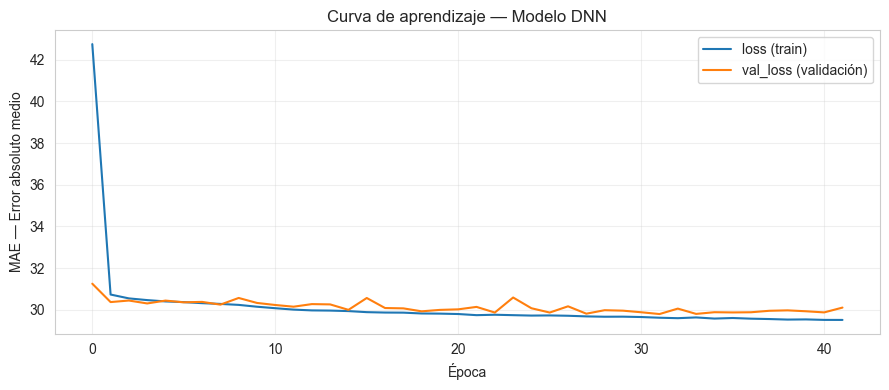

MAE final entrenamiento: 29.520
MAE final validación:    30.112


In [40]:
# Curva de aprendizaje
plt.figure(figsize=(9, 4))
plt.plot(history_dnn.history['loss'], label='loss (train)')
plt.plot(history_dnn.history['val_loss'], label='val_loss (validación)')
plt.xlabel('Época')
plt.ylabel('MAE — Error absoluto medio')
plt.title('Curva de aprendizaje — Modelo DNN')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE final entrenamiento: {history_dnn.history['loss'][-1]:.3f}")
print(f"MAE final validación:    {history_dnn.history['val_loss'][-1]:.3f}")

In [41]:
# Predicciones y métricas en test
predicciones_dnn = modelo_dnn.predict(test_X, verbose=0).flatten()

mae_dnn = mean_absolute_error(test_y, predicciones_dnn)
rmse_dnn = np.sqrt(mean_squared_error(test_y, predicciones_dnn))
r2_dnn = r2_score(test_y, predicciones_dnn)

resultados['Modelo DNN (64, 64)'] = {
    'MAE_test': round(mae_dnn, 3),
    'RMSE_test': round(rmse_dnn, 3),
    'R2_test': round(r2_dnn, 3),
}

print(f"--- Modelo DNN (64, 64) ---")
print(f"MAE  test: {mae_dnn:.3f}")
print(f"RMSE test: {rmse_dnn:.3f}")
print(f"R²   test: {r2_dnn:.3f}")

--- Modelo DNN (64, 64) ---
MAE  test: 29.872
RMSE test: 38.086
R²   test: 0.389


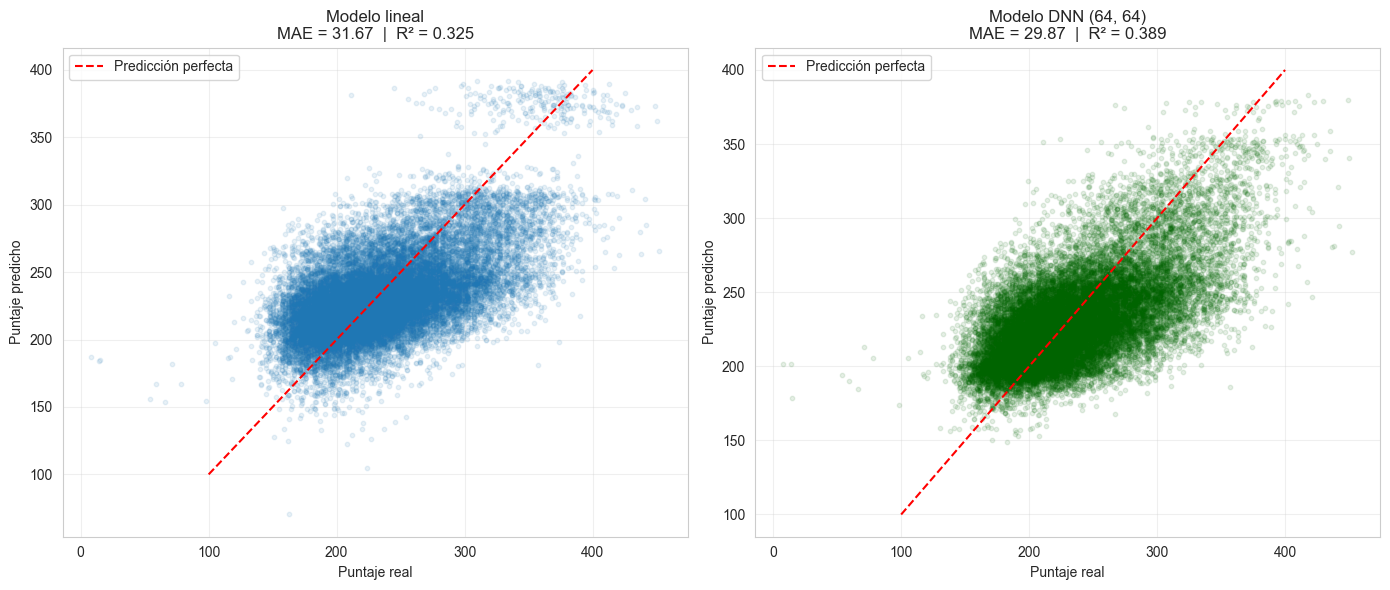

In [42]:
# Comparación visual: lineal vs DNN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(test_y, predicciones_lineal, alpha=0.1, s=10)
axes[0].plot([100, 400], [100, 400], 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Puntaje real')
axes[0].set_ylabel('Puntaje predicho')
axes[0].set_title(f'Modelo lineal\nMAE = {mae_lineal:.2f}  |  R² = {r2_lineal:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(test_y, predicciones_dnn, alpha=0.1, s=10, color='darkgreen')
axes[1].plot([100, 400], [100, 400], 'r--', label='Predicción perfecta')
axes[1].set_xlabel('Puntaje real')
axes[1].set_ylabel('Puntaje predicho')
axes[1].set_title(f'Modelo DNN (64, 64)\nMAE = {mae_dnn:.2f}  |  R² = {r2_dnn:.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Tabla resumen de modelos
df_resultados = pd.DataFrame(resultados).T
print("Comparación de modelos:\n")
print(df_resultados.to_string())

Comparación de modelos:

                     MAE_test  RMSE_test  R2_test
Modelo lineal          31.667     40.052    0.325
Modelo DNN (64, 64)    29.872     38.086    0.389


## 8. Experimentación con MLflow

Probamos distintas configuraciones del modelo DNN variando arquitectura, regularización y learning rate. Cada experimento se registra en **MLflow** para facilitar la comparación sistemática.

Los hiperparámetros que exploramos son:
- **Profundidad**: 2 vs 3 capas ocultas.
- **Ancho**: 32, 64 o 128 neuronas por capa.
- **Regularización**: con y sin Dropout (tasa 0.2).
- **Learning rate**: 0.001 y 0.0005.

Para cada experimento se registran:
- Hiperparámetros (arquitectura, learning rate, dropout, batch size).
- Métricas finales en test (MAE, RMSE, R²).
- Curva de entrenamiento.
- Número de épocas efectivas (gracias al early stopping).

In [44]:
# Instalación de MLflow 
#!pip install mlflow --quiet

In [45]:
import mlflow
import mlflow.tensorflow
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Saber11_Bolivar_Regresion")

print("MLflow configurado.")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

MLflow configurado.
Tracking URI: file:./mlruns


In [46]:
def entrenar_y_registrar(
    nombre_run,
    capas_ocultas,
    learning_rate=0.001,
    dropout=0.0,
    epochs=100,
    patience=10,
    batch_size=32,
):
    """Entrena un modelo DNN con la arquitectura indicada y registra todo en MLflow."""
    
    with mlflow.start_run(run_name=nombre_run):
        capas = [tf.keras.layers.Input(shape=(n_features,)), normalizador]
        for unidades in capas_ocultas:
            capas.append(tf.keras.layers.Dense(unidades, activation='relu'))
            if dropout > 0:
                capas.append(tf.keras.layers.Dropout(dropout))
        capas.append(tf.keras.layers.Dense(1))
        
        modelo = tf.keras.Sequential(capas)
        modelo.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss='mean_absolute_error'
        )
        
        mlflow.log_param("arquitectura", str(capas_ocultas))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("dropout", dropout)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("epochs_max", epochs)
        
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0
        )
        
        history = modelo.fit(
            train_X, train_y,
            epochs=epochs,
            validation_split=0.2,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )
        
        pred = modelo.predict(test_X, verbose=0).flatten()
        mae = mean_absolute_error(test_y, pred)
        rmse = np.sqrt(mean_squared_error(test_y, pred))
        r2 = r2_score(test_y, pred)
        epocas_efectivas = len(history.history['loss'])
        
        mlflow.log_metric("MAE_test", mae)
        mlflow.log_metric("RMSE_test", rmse)
        mlflow.log_metric("R2_test", r2)
        mlflow.log_metric("epocas_efectivas", epocas_efectivas)
        mlflow.log_metric("MAE_train_final", history.history['loss'][-1])
        mlflow.log_metric("MAE_val_final", history.history['val_loss'][-1])
        
        print(f"[{nombre_run}] MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  épocas={epocas_efectivas}")
        
        return modelo, history, {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'epocas': epocas_efectivas}

print("Función de entrenamiento lista.")

Función de entrenamiento lista.


In [47]:
# Diccionario para guardar todos los experimentos
experimentos = {}

# Experimento 1: arquitectura más simple
modelo_1, h1, m1 = entrenar_y_registrar(
    nombre_run="DNN_32x32",
    capas_ocultas=[32, 32],
    learning_rate=0.001,
    dropout=0.0,
)
experimentos['DNN_32x32'] = m1

[DNN_32x32] MAE=30.064  RMSE=38.204  R²=0.386  épocas=53


In [48]:
# Experimento 2: más ancho
modelo_2, h2, m2 = entrenar_y_registrar(
    nombre_run="DNN_128x64",
    capas_ocultas=[128, 64],
    learning_rate=0.001,
    dropout=0.0,
)
experimentos['DNN_128x64'] = m2

[DNN_128x64] MAE=29.730  RMSE=37.885  R²=0.396  épocas=55


In [49]:
# Experimento 3: más profundo
modelo_3, h3, m3 = entrenar_y_registrar(
    nombre_run="DNN_128x64x32",
    capas_ocultas=[128, 64, 32],
    learning_rate=0.001,
    dropout=0.0,
)
experimentos['DNN_128x64x32'] = m3

[DNN_128x64x32] MAE=29.826  RMSE=38.034  R²=0.391  épocas=42


In [50]:
# Experimento 4: con dropout (regularización)
modelo_4, h4, m4 = entrenar_y_registrar(
    nombre_run="DNN_128x64_dropout",
    capas_ocultas=[128, 64],
    learning_rate=0.001,
    dropout=0.2,
)
experimentos['DNN_128x64_dropout'] = m4

[DNN_128x64_dropout] MAE=30.143  RMSE=38.458  R²=0.377  épocas=41


In [51]:
# Experimento 5: learning rate más bajo
modelo_5, h5, m5 = entrenar_y_registrar(
    nombre_run="DNN_128x64_lr0.0005",
    capas_ocultas=[128, 64],
    learning_rate=0.0005,
    dropout=0.0,
)
experimentos['DNN_128x64_lr0.0005'] = m5

[DNN_128x64_lr0.0005] MAE=29.760  RMSE=37.876  R²=0.396  épocas=49


In [52]:
# Resumen comparativo de todos los experimentos
print("=" * 75)
print("RESUMEN DE EXPERIMENTOS")
print("=" * 75)

df_experimentos = pd.DataFrame(experimentos).T
df_experimentos = df_experimentos.sort_values('MAE')
print(df_experimentos.to_string())

# Agregamos también los modelos anteriores para comparación completa
print("\n" + "=" * 75)
print("COMPARACIÓN GENERAL (incluyendo modelos anteriores)")
print("=" * 75)
print(pd.DataFrame(resultados).T.to_string())

RESUMEN DE EXPERIMENTOS
                           MAE       RMSE        R2  epocas
DNN_128x64           29.729847  37.885199  0.395809    55.0
DNN_128x64_lr0.0005  29.760364  37.875935  0.396104    49.0
DNN_128x64x32        29.826187  38.034136  0.391049    42.0
DNN_32x32            30.064065  38.204300  0.385588    53.0
DNN_128x64_dropout   30.143481  38.457692  0.377411    41.0

COMPARACIÓN GENERAL (incluyendo modelos anteriores)
                     MAE_test  RMSE_test  R2_test
Modelo lineal          31.667     40.052    0.325
Modelo DNN (64, 64)    29.872     38.086    0.389


## 9. Modelo de comparación: Gradient Boosting (benchmark)

Para validar que el desempeño de la red neuronal no está limitado por la elección del algoritmo, entrenamos un modelo de **Gradient Boosting** usando exactamente las mismas features que la red. Esto permite una comparación justa entre paradigmas: redes neuronales vs. árboles de decisión potenciados.

Usamos `HistGradientBoostingRegressor` de scikit-learn, una implementación eficiente de Gradient Boosting muy competitiva en datos tabulares (similar en espíritu a XGBoost o LightGBM). Sirve como referencia sólida: si ambos modelos convergen a un desempeño similar, se confirma que el límite predictivo proviene de la información disponible en las variables y no del modelo elegido.

La red neuronal se mantiene como el modelo principal del proyecto (requisito del enunciado); el Gradient Boosting cumple un rol de benchmark comparativo.

In [62]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Entrenamos Gradient Boosting con las MISMAS features que la red (comparación justa)
with mlflow.start_run(run_name="GradientBoosting_benchmark"):
    modelo_gb = HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
    )
    
    mlflow.log_param("modelo", "HistGradientBoosting")
    mlflow.log_param("max_iter", 300)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    
    modelo_gb.fit(train_X, train_y)
    
    pred_gb = modelo_gb.predict(test_X)
    mae_gb = mean_absolute_error(test_y, pred_gb)
    rmse_gb = np.sqrt(mean_squared_error(test_y, pred_gb))
    r2_gb = r2_score(test_y, pred_gb)
    
    mlflow.log_metric("MAE_test", mae_gb)
    mlflow.log_metric("RMSE_test", rmse_gb)
    mlflow.log_metric("R2_test", r2_gb)
    
    print(f"Gradient Boosting → MAE={mae_gb:.3f}  RMSE={rmse_gb:.3f}  R²={r2_gb:.3f}")

resultados['Gradient Boosting'] = {
    'MAE_test': round(mae_gb, 3),
    'RMSE_test': round(rmse_gb, 3),
    'R2_test': round(r2_gb, 3),
}

Gradient Boosting → MAE=29.549  RMSE=37.330  R²=0.413


In [63]:
print("=" * 70)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 70)
df_final_comparacion = pd.DataFrame(resultados).T.sort_values('MAE_test')
print(df_final_comparacion.to_string())

COMPARACIÓN FINAL DE MODELOS
                     MAE_test  RMSE_test  R2_test
Gradient Boosting      29.549     37.330    0.413
Modelo DNN (64, 64)    29.872     38.086    0.389
Modelo lineal          31.667     40.052    0.325


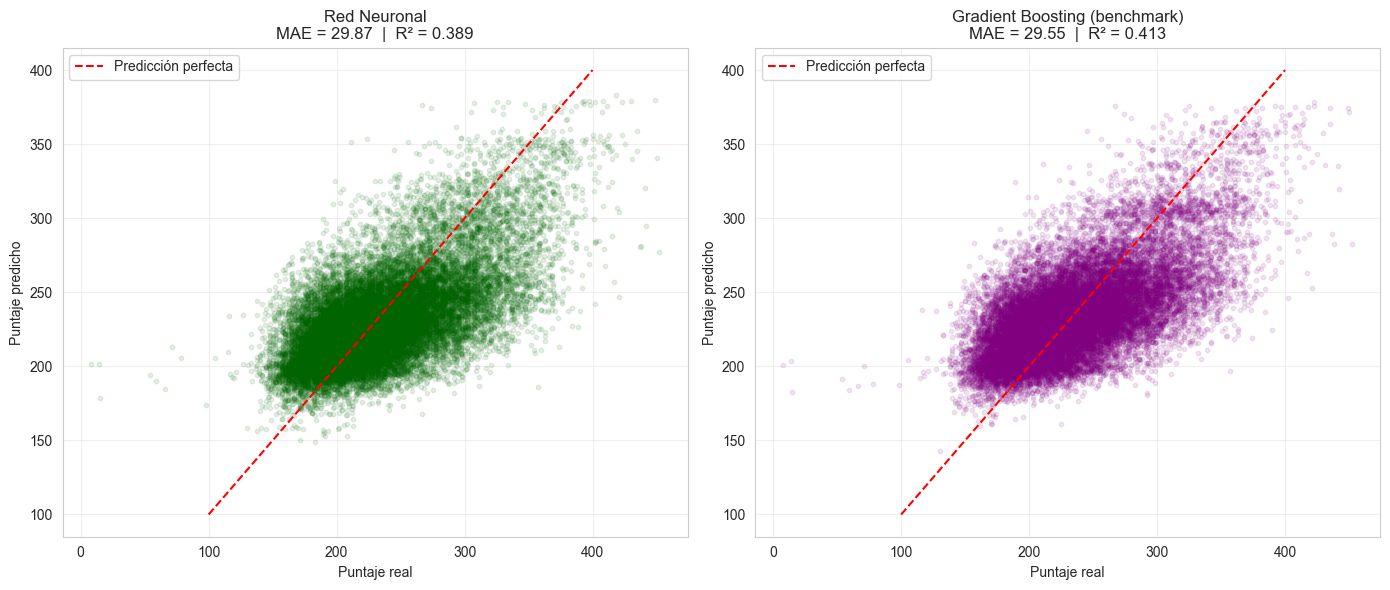

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(test_y, predicciones_dnn, alpha=0.1, s=10, color='darkgreen')
axes[0].plot([100, 400], [100, 400], 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Puntaje real')
axes[0].set_ylabel('Puntaje predicho')
axes[0].set_title(f'Red Neuronal\nMAE = {mae_dnn:.2f}  |  R² = {r2_dnn:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(test_y, pred_gb, alpha=0.1, s=10, color='purple')
axes[1].plot([100, 400], [100, 400], 'r--', label='Predicción perfecta')
axes[1].set_xlabel('Puntaje real')
axes[1].set_ylabel('Puntaje predicho')
axes[1].set_title(f'Gradient Boosting (benchmark)\nMAE = {mae_gb:.2f}  |  R² = {r2_gb:.3f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Consolidamos TODOS los modelos en una sola tabla comparativa
# (incluyendo los experimentos de MLflow que no quedaron en 'resultados')

comparacion_completa = {
    'Modelo lineal':            {'MAE_test': 31.667, 'RMSE_test': 40.052, 'R2_test': 0.325},
    'DNN (64, 64)':             {'MAE_test': 29.872, 'RMSE_test': 38.086, 'R2_test': 0.389},
    'DNN (32, 32)':             {'MAE_test': 30.064, 'RMSE_test': 38.204, 'R2_test': 0.386},
    'DNN (128, 64)':            {'MAE_test': 29.730, 'RMSE_test': 37.885, 'R2_test': 0.396},
    'DNN (128, 64, 32)':        {'MAE_test': 29.826, 'RMSE_test': 38.034, 'R2_test': 0.391},
    'DNN (128, 64) + Dropout':  {'MAE_test': 30.143, 'RMSE_test': 38.458, 'R2_test': 0.377},
    'DNN (128, 64) lr=0.0005':  {'MAE_test': 29.760, 'RMSE_test': 37.876, 'R2_test': 0.396},
    'Gradient Boosting':        {'MAE_test': 29.549, 'RMSE_test': 37.330, 'R2_test': 0.413},
}

df_comparacion = pd.DataFrame(comparacion_completa).T.sort_values('MAE_test')
print("=" * 75)
print("COMPARACIÓN COMPLETA DE TODOS LOS MODELOS")
print("=" * 75)
print(df_comparacion.to_string())

COMPARACIÓN COMPLETA DE TODOS LOS MODELOS
                         MAE_test  RMSE_test  R2_test
Gradient Boosting          29.549     37.330    0.413
DNN (128, 64)              29.730     37.885    0.396
DNN (128, 64) lr=0.0005    29.760     37.876    0.396
DNN (128, 64, 32)          29.826     38.034    0.391
DNN (64, 64)               29.872     38.086    0.389
DNN (32, 32)               30.064     38.204    0.386
DNN (128, 64) + Dropout    30.143     38.458    0.377
Modelo lineal              31.667     40.052    0.325


## 10. Modelo final y serialización

Tras la experimentación, seleccionamos la **red neuronal DNN (128, 64)** como modelo final del proyecto. Aunque el benchmark de Gradient Boosting obtuvo un R² marginalmente superior (0.413 vs 0.396), la diferencia es mínima (0.017) y el enunciado requiere una red neuronal como modelo principal.

Re-entrenamos el modelo de forma limpia y lo serializamos junto con los artefactos necesarios para el despliegue:
- El modelo entrenado (`.keras`), que incluye la capa de normalización.
- Los mapeos de codificación de variables (estrato, educación, etc.).
- La lista ordenada de columnas que el modelo espera como entrada.

Estos artefactos permiten que el tablero cargue el modelo pre-entrenado y procese correctamente los datos ingresados por el usuario, sin necesidad de re-entrenar.

In [66]:
# Re-entrenamos el DNN (128, 64) — modelo final — guardándolo en variable
print("Entrenando modelo final DNN (128, 64)...")

modelo_final = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    normalizador,
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

modelo_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

history_final = modelo_final.fit(
    train_X, train_y,
    epochs=100, validation_split=0.2,
    callbacks=[early_stop], verbose=0
)

# Métricas del modelo final
pred_final = modelo_final.predict(test_X, verbose=0).flatten()
mae_final = mean_absolute_error(test_y, pred_final)
r2_final = r2_score(test_y, pred_final)
print(f"\nModelo final → MAE={mae_final:.3f}  R²={r2_final:.3f}")
print(f"Épocas efectivas: {len(history_final.history['loss'])}")

Entrenando modelo final DNN (128, 64)...
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 46.

Modelo final → MAE=29.723  R²=0.399
Épocas efectivas: 56


In [67]:
import os

# Creamos una carpeta para los artefactos del modelo
os.makedirs('modelo_serializado', exist_ok=True)

# Guardamos el modelo en formato .keras (recomendado por TensorFlow)
modelo_final.save('modelo_serializado/modelo_saber11.keras')
print("Modelo guardado en: modelo_serializado/modelo_saber11.keras")

Modelo guardado en: modelo_serializado/modelo_saber11.keras


In [68]:
import json

# Guardamos todo lo que el dashboard necesita para procesar el input del usuario
artefactos = {
    # Lista ordenada de columnas que el modelo espera (¡el orden importa!)
    'columnas_modelo': list(train_X.columns),
    
    # Mapeos de variables binarias
    'mapeo_bilingue': {'S': 1, 'N': 0},
    'mapeo_area': {'URBANO': 1, 'RURAL': 0},
    'mapeo_naturaleza': {'NO OFICIAL': 1, 'OFICIAL': 0},
    'mapeo_si_no': {'SI': 1, 'Si': 1, 'NO': 0, 'No': 0},
    'mapeo_genero_estu': {'M': 1, 'F': 0},
    
    # Mapeos ordinales
    'mapeo_estrato': mapa_estrato,
    'mapeo_educacion': mapa_educacion,
    'mapeo_cuartos': mapa_cuartos,
    'mapeo_personas': mapa_personas,
    
    # Categorías de las variables nominales (para los dropdowns del dashboard)
    'categorias_caracter': ['ACADEMICO', 'TECNICO', 'TECNICO/ACADEMICO', 'NO APLICA'],
    'categorias_jornada': ['MAÑANA', 'TARDE', 'NOCHE', 'COMPLETA', 'SABATINA', 'UNICA'],
    'categorias_genero_cole': ['MIXTO', 'MASCULINO', 'FEMENINO'],
    'categorias_calendario': ['A', 'B'],
    
    # Metadata útil
    'metricas': {'MAE': round(mae_final, 3), 'R2': round(r2_final, 3)},
}

with open('modelo_serializado/artefactos.json', 'w', encoding='utf-8') as f:
    json.dump(artefactos, f, ensure_ascii=False, indent=2)

print("Artefactos guardados en: modelo_serializado/artefactos.json")
print(f"\nEl modelo espera {len(artefactos['columnas_modelo'])} columnas en este orden:")
for i, col in enumerate(artefactos['columnas_modelo']):
    print(f"  {i+1}. {col}")

Artefactos guardados en: modelo_serializado/artefactos.json

El modelo espera 29 columnas en este orden:
  1. cole_bilingue
  2. cole_area_ubicacion
  3. cole_naturaleza
  4. fami_tieneautomovil
  5. fami_tienecomputador
  6. fami_tieneinternet
  7. fami_tienelavadora
  8. estu_genero
  9. fami_estratovivienda
  10. fami_educacionmadre
  11. fami_educacionpadre
  12. fami_cuartoshogar
  13. fami_personashogar
  14. edad
  15. cole_calendario_A
  16. cole_calendario_B
  17. cole_caracter_ACADEMICO
  18. cole_caracter_NO APLICA
  19. cole_caracter_TECNICO
  20. cole_caracter_TECNICO/ACADEMICO
  21. cole_jornada_COMPLETA
  22. cole_jornada_MAÑANA
  23. cole_jornada_NOCHE
  24. cole_jornada_SABATINA
  25. cole_jornada_TARDE
  26. cole_jornada_UNICA
  27. cole_genero_FEMENINO
  28. cole_genero_MASCULINO
  29. cole_genero_MIXTO


In [69]:
# VERIFICACIÓN CRÍTICA: cargamos el modelo guardado y confirmamos que predice igual
modelo_cargado = tf.keras.models.load_model('modelo_serializado/modelo_saber11.keras')

# Predecimos con el modelo cargado sobre las mismas 5 primeras filas de test
pred_original = modelo_final.predict(test_X.iloc[:5], verbose=0).flatten()
pred_recargado = modelo_cargado.predict(test_X.iloc[:5], verbose=0).flatten()

print("Comparación de predicciones (modelo original vs recargado):")
for i in range(5):
    print(f"  Fila {i}: original={pred_original[i]:.2f}  recargado={pred_recargado[i]:.2f}")

# Verificamos que sean idénticas
if np.allclose(pred_original, pred_recargado):
    print("\nPERFECTO: el modelo guardado predice exactamente igual que el original.")
else:
    print("\nALERTA: hay diferencias entre el modelo original y el recargado.")

Comparación de predicciones (modelo original vs recargado):
  Fila 0: original=214.48  recargado=214.48
  Fila 1: original=253.79  recargado=253.79
  Fila 2: original=219.39  recargado=219.39
  Fila 3: original=209.02  recargado=209.02
  Fila 4: original=193.38  recargado=193.38

PERFECTO: el modelo guardado predice exactamente igual que el original.
